# Mejora 2 - Validación cruzada repetida para decidir los empates

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

En el notebook principal varias decisiones quedaron prácticamente empatadas: el rango de n-gramas de cada bloque, la lista de conectores, el stemming. Las diferencias entre las alternativas (menos de 0,1 puntos de F1-macro) eran mucho menores que la desviación entre las particiones de la validación cruzada (entre 0,7 y 1,3 puntos), así que con una sola validación cruzada de 5 particiones no se podía saber si alguna alternativa era realmente mejor.

Este notebook implementa la segunda oportunidad de mejora: **repetir la validación cruzada con varias semillas y comparar las alternativas de forma pareada**, para decidir con más información. Es una mejora del proceso de decisión y no tanto del modelo: puede que el resultado sea confirmar la configuración actual.

## Requisitos de la guía

| Requisito | Cómo se cumple |
|:---|:---|
| No usar aprendizaje profundo, transformers ni embeddings preentrenados. | No se usa ninguno. Todo se basa en TF-IDF y n-gramas. |
| Usar únicamente modelos de scikit-learn. | Solo `LogisticRegression`. |
| Resultados replicables. | Semillas fijas, versiones en `requirements.txt` y todo el flujo en este notebook (sección 15). |

## 1. Importación de librerías

In [1]:
import os
import re
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

try:
    stopwords.words('spanish')
except LookupError:
    nltk.download('stopwords')

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
NOMBRE_MODELO = 'regresion_logistica_cv_repetida'

os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 2. Datos y partición

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra_envio.shape)
print('Distribución de clases en train:')
display(train['label'].value_counts(normalize=True).reindex(ORDEN_CLASES).round(3).to_frame('proporción'))

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)
Distribución de clases en train:


,proporción
label,
negativo,0.351
neutral,0.298
positivo,0.351


In [3]:
X = train[['text']]
y = train['label']

# Misma partición y mismas particiones de validación cruzada que en el notebook principal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

Entrenamiento: (9600, 1) | Prueba: (2400, 1)


## 3. Representación configurable

Para poder comparar alternativas, la extracción de texto y la representación del notebook principal se generalizan con parámetros: qué parte de la reseña se extrae, la lista de conectores, si se aplica stemming, si se eliminan stop words, el rango de n-gramas de cada bloque y si se usa el bloque de cláusula final. El argumento `kw_args` de `FunctionTransformer` permite pasar esos parámetros a la función de extracción.

Con los valores por defecto, `construir_modelo()` reproduce exactamente el modelo del notebook principal (regresión logística L1 con `C = 10` sobre los tres bloques).

In [4]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Listas de conectores de contraste que se van a comparar
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'
CONECTORES_MAS_ESO_SI = r'\b(?:pero|aunque|sin embargo|en cambio|eso si|aun asi|con todo|a fin de cuentas|al final)\b'
CONECTORES_AMPLIADOS = (r'\b(?:pero|aunque|sin embargo|en cambio|eso si|aun asi|aun con|con todo|'
                        r'a fin de cuentas|al final|lo unico|lo que|ahora|por el lado de|igual)\b')

# Stop words de NLTK sin tildes, y la misma lista sin las palabras de negación o contraste
stop_nltk = {quitar_tildes(p) for p in stopwords.words('spanish')}
negaciones = {'no', 'ni', 'nada', 'nunca', 'ningun', 'sin', 'pero', 'muy', 'mas', 'poco',
              'mucho', 'tanto', 'si', 'aunque'}
stop_sin_negaciones = stop_nltk - negaciones


def extraer_texto(textos, parte='completo', conectores=CONECTORES, stemming=True, stop=None):
    """Extrae y limpia una parte de cada reseña: el texto completo, la última oración
    o la cláusula que sigue al último conector de contraste de la última oración."""
    salida = []
    for texto in textos:
        ultima = separar_oraciones(texto)[-1]
        if parte == 'completo':
            fragmento = texto
        elif parte == 'ultima':
            fragmento = ultima
        else:
            fragmento = re.split(conectores, quitar_tildes(ultima.lower()))[-1]
        salida.append(limpiar_texto(fragmento, stop=stop, stemming=stemming))
    return salida


def construir_representacion(rangos=((1, 2), (1, 2), (1, 2)), conectores=CONECTORES,
                             stemming=True, stop=None, usar_clausula=True):
    partes = ['completo', 'ultima'] + (['clausula'] if usar_clausula else [])
    bloques = []
    for parte, rango in zip(partes, rangos):
        parametros = {'parte': parte, 'conectores': conectores, 'stemming': stemming, 'stop': stop}
        bloques.append((parte,
                        Pipeline([('extraer', FunctionTransformer(extraer_texto, kw_args=parametros)),
                                  ('tfidf', TfidfVectorizer(ngram_range=rango))]),
                        'text'))
    return ColumnTransformer(bloques)


def construir_modelo(**configuracion):
    return Pipeline([
        ('rep', construir_representacion(**configuracion)),
        ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE)),
    ])

In [5]:
def metricas(y_real, y_pred):
    return {'Exactitud': accuracy_score(y_real, y_pred),
            'Precisión (macro)': precision_score(y_real, y_pred, average='macro'),
            'Recall (macro)': recall_score(y_real, y_pred, average='macro'),
            'F1 (macro)': f1_score(y_real, y_pred, average='macro')}

## 4. ¿Cuánto ruido tiene una validación cruzada?

Una validación cruzada de 5 particiones da un solo número que depende de cómo se repartieron las reseñas. Para medir cuánto, se repite 3 veces con semillas distintas (15 particiones en total) y todas las configuraciones se evalúan **exactamente sobre las mismas 15 particiones**. Esto es lo que permite una comparación pareada: las diferencias entre dos alternativas, partición por partición, tienen mucho menos ruido que los puntajes individuales.

In [6]:
# 3 repeticiones de validación cruzada de 5 particiones con semillas distintas = 15 particiones.
# Todas las configuraciones se evalúan exactamente sobre las mismas 15 particiones.
semillas = [1, 2, 3]
particiones = []
for semilla in semillas:
    particiones += list(StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla).split(X_train, y_train))

puntajes = {}


def evaluar(nombre, **configuracion):
    puntajes[nombre] = cross_val_score(construir_modelo(**configuracion), X_train, y_train,
                                       cv=particiones, scoring='f1_macro', n_jobs=-1)
    return puntajes[nombre]


referencia = {}      # configuración actual: n-gramas (1, 2) en los tres bloques y la lista original de conectores
evaluar('Referencia (modelo actual)', **referencia)
ref = puntajes['Referencia (modelo actual)']

por_repeticion = ref.reshape(3, 5)
print('F1-macro de la referencia en cada una de las 15 particiones:')
print(np.round(ref, 4))
print(f'\nMedia de las 15 particiones: {ref.mean():.4f} | desviación entre particiones: {ref.std(ddof=1):.4f}')
print('Media de cada repetición de 5 particiones:', np.round(por_repeticion.mean(axis=1), 4))
print(f'Con una sola validación cruzada (semilla {RANDOM_STATE}) el notebook principal obtuvo 0.8992')

F1-macro de la referencia en cada una de las 15 particiones:
[0.8916 0.8984 0.8965 0.9012 0.9004 0.8916 0.9052 0.9014 0.8898 0.888
 0.9035 0.9006 0.898  0.8955 0.8884]

Media de las 15 particiones: 0.8967 | desviación entre particiones: 0.0056
Media de cada repetición de 5 particiones: [0.8976 0.8952 0.8972]
Con una sola validación cruzada (semilla 42) el notebook principal obtuvo 0.8992


El F1-macro de la configuración actual varía entre 0,888 y 0,905 según la partición (desviación de 0,0056) y su media en las 15 particiones es de 0,8967. Las tres repeticiones de 5 particiones dan medias de 0,8976, 0,8952 y 0,8972. El notebook principal obtuvo 0,8992 con una sola validación cruzada, es decir, unos 0,25 puntos por encima de la media de las 15 particiones. Una sola validación cruzada puede sobrestimar (o subestimar) el desempeño en unas pocas décimas de punto, y esa es la escala de las diferencias que se quieren decidir.

## 5. Cómo se decide si una alternativa es mejor

Para cada alternativa se calcula, partición por partición, la diferencia de F1-macro frente a la configuración actual. A partir de las 15 diferencias se obtienen su media, su error estándar (desviación dividida por la raíz de 15) y en cuántas particiones la alternativa gana. La regla de decisión es:

- **MEJORA:** la diferencia media es mayor que 2 errores estándar y la alternativa gana en al menos 12 de las 15 particiones.
- **empeora:** la diferencia media es menor que −2 errores estándar y la alternativa gana en 3 particiones o menos.
- **empate:** en cualquier otro caso. Ante un empate se mantiene la configuración actual, que es la más simple o la ya conocida.

Hay una advertencia: las 15 particiones comparten reseñas (cada reseña aparece en las particiones de prueba de las tres repeticiones), por lo que no son independientes y el error estándar es algo optimista. La regla es una guía para decidir y no una prueba estadística formal.

In [7]:
def comparar(candidatos):
    """Compara cada candidato con la referencia usando las mismas 15 particiones."""
    filas = []
    for nombre in candidatos:
        diferencia = puntajes[nombre] - ref
        error = diferencia.std(ddof=1) / np.sqrt(len(diferencia))
        gana = int((diferencia > 0).sum())
        if diferencia.mean() > 2 * error and gana >= 12:
            veredicto = 'MEJORA'
        elif diferencia.mean() < -2 * error and gana <= 3:
            veredicto = 'empeora'
        else:
            veredicto = 'empate'
        filas.append({'Alternativa': nombre, 'F1-macro medio': puntajes[nombre].mean(),
                      'Diferencia media': diferencia.mean(), 'Error estándar': error,
                      'Mejora en (de 15)': gana, 'Veredicto': veredicto})
    return pd.DataFrame(filas).set_index('Alternativa')

## 6. Decisión 1: rango de n-gramas en cada bloque

In [8]:
configuraciones = {}

for bloque, posicion in [('texto completo', 0), ('última oración', 1), ('cláusula final', 2)]:
    for rango in [(1, 1), (1, 3)]:
        rangos = [(1, 2), (1, 2), (1, 2)]
        rangos[posicion] = rango
        nombre = f'{bloque}: n-gramas {rango}'
        configuraciones[nombre] = {'rangos': tuple(rangos)}
        evaluar(nombre, **configuraciones[nombre])

for rango in [(1, 1), (1, 3)]:
    nombre = f'los tres bloques: n-gramas {rango}'
    configuraciones[nombre] = {'rangos': (rango, rango, rango)}
    evaluar(nombre, **configuraciones[nombre])

tabla_d1 = comparar([n for n in configuraciones])
tabla_d1.round(4)

,F1-macro medio,Diferencia media,Error estándar,Mejora en (de 15),Veredicto
Alternativa,,,,,
"texto completo: n-gramas (1, 1)",0.8947,-0.0020,0.0010,4,empate
"texto completo: n-gramas (1, 3)",0.8954,-0.0013,0.0008,6,empate
"última oración: n-gramas (1, 1)",0.8937,-0.0029,0.0009,3,empeora
"última oración: n-gramas (1, 3)",0.8958,-0.0009,0.0007,7,empate
"cláusula final: n-gramas (1, 1)",0.8925,-0.0042,0.0010,2,empeora
"cláusula final: n-gramas (1, 3)",0.8972,0.0006,0.0007,8,empate
"los tres bloques: n-gramas (1, 1)",0.8850,-0.0116,0.0012,0,empeora
"los tres bloques: n-gramas (1, 3)",0.8975,0.0008,0.0009,9,empate


- Pasar a unigramas en los tres bloques **empeora** 1,16 puntos, y en ninguna de las 15 particiones gana. Los bigramas importan (por ejemplo, para capturar "no vale" o "poco fiable").
- Quitar los bigramas solo en la última oración (−0,29) o solo en la cláusula final (−0,42) también empeora. En el texto completo la diferencia (−0,20) queda en empate.
- Los trigramas dan diferencias pequeñas a favor (+0,06 en la cláusula final y +0,08 en los tres bloques), pero con errores estándar de 0,07 y 0,09 puntos y ganando solo en 8 y 9 de las 15 particiones. Es un empate: se mantienen los bigramas, que son más simples.

## 7. Decisión 2: bloque de cláusula final y lista de conectores

In [9]:
configuraciones_d2 = {
    'conectores + "eso sí" y "en cambio"': {'conectores': CONECTORES_MAS_ESO_SI},
    'lista ampliada de conectores': {'conectores': CONECTORES_AMPLIADOS},
    'sin el bloque de cláusula final': {'usar_clausula': False},
}
for nombre, configuracion in configuraciones_d2.items():
    evaluar(nombre, **configuracion)
configuraciones.update(configuraciones_d2)

tabla_d2 = comparar(list(configuraciones_d2))
tabla_d2.round(4)

,F1-macro medio,Diferencia media,Error estándar,Mejora en (de 15),Veredicto
Alternativa,,,,,
"conectores + ""eso sí"" y ""en cambio""",0.8967,0.0001,0.0004,9,empate
lista ampliada de conectores,0.8936,-0.0031,0.0011,2,empeora
sin el bloque de cláusula final,0.8899,-0.0067,0.0009,0,empeora


- **Quitar el bloque de cláusula final empeora 0,67 puntos** y no gana en ninguna partición. Esto confirma, con más evidencia, que el bloque de cláusula final aporta.
- La lista ampliada de conectores empeora 0,31 puntos (gana en 2 de 15): más conectores no es mejor.
- Agregar "eso sí" y "en cambio" a la lista original es un empate (+0,01 puntos).

## 8. Decisión 3: preprocesamiento

In [10]:
configuraciones_d3 = {
    'sin stemming': {'stemming': False},
    'con stop words (NLTK sin negaciones)': {'stop': stop_sin_negaciones},
}
for nombre, configuracion in configuraciones_d3.items():
    evaluar(nombre, **configuracion)
configuraciones.update(configuraciones_d3)

tabla_d3 = comparar(list(configuraciones_d3))
tabla_d3.round(4)

,F1-macro medio,Diferencia media,Error estándar,Mejora en (de 15),Veredicto
Alternativa,,,,,
sin stemming,0.8971,0.0004,0.0009,7,empate
con stop words (NLTK sin negaciones),0.8968,0.0001,0.0010,8,empate


Ni quitar el stemming (+0,04 puntos) ni eliminar stop words conservando las negaciones (+0,01 puntos) cambian el resultado: ambos son empates. Con esta representación el preprocesamiento es poco influyente. Se mantiene el stemming, que hace parte del pipeline visto en clase, y no se eliminan stop words.

## 9. Resumen de las decisiones

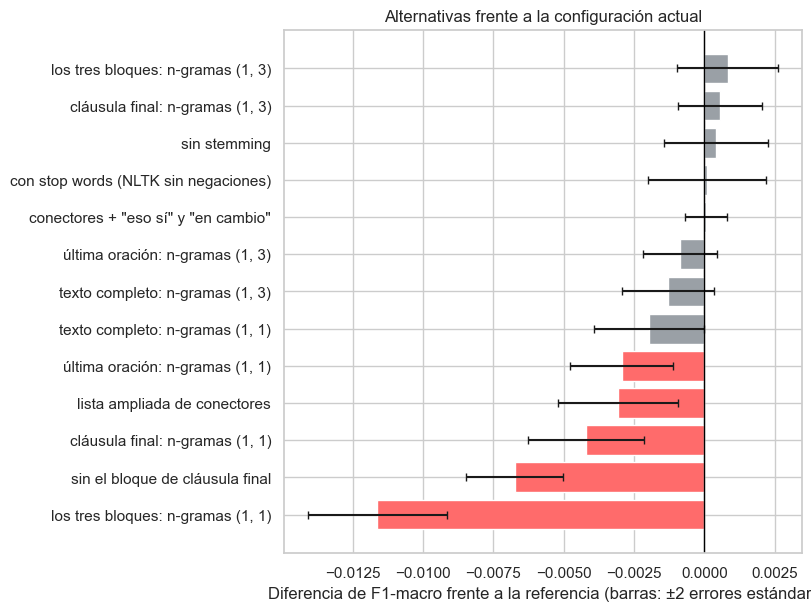

Alternativas que mejoran: ninguna
Alternativas que empeoran: ['última oración: n-gramas (1, 1)', 'lista ampliada de conectores', 'cláusula final: n-gramas (1, 1)', 'sin el bloque de cláusula final', 'los tres bloques: n-gramas (1, 1)']


In [11]:
resumen = pd.concat([tabla_d1, tabla_d2, tabla_d3]).sort_values('Diferencia media', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
colores = resumen['Veredicto'].map({'MEJORA': '#51CF66', 'empate': '#9AA0A6', 'empeora': '#FF6B6B'})
ax.barh(resumen.index[::-1], resumen['Diferencia media'][::-1], xerr=2 * resumen['Error estándar'][::-1],
        color=list(colores[::-1]), capsize=3)
ax.axvline(0, color='black', linewidth=1)
ax.set(xlabel='Diferencia de F1-macro frente a la referencia (barras: ±2 errores estándar)',
       title='Alternativas frente a la configuración actual')
plt.show()

print('Alternativas que mejoran:', list(resumen.index[resumen['Veredicto'] == 'MEJORA']) or 'ninguna')
print('Alternativas que empeoran:', list(resumen.index[resumen['Veredicto'] == 'empeora']) or 'ninguna')

Ninguna alternativa mejora a la configuración actual. Cinco empeoran (unigramas en los tres bloques, unigramas en la última oración, unigramas en la cláusula final, lista ampliada de conectores y quitar la cláusula final) y las otras ocho empatan. Es decir, las decisiones que se tomaron en el notebook principal quedan respaldadas: las que se creían importantes (bigramas, bloque de cláusula final) lo son, y las que se creían indiferentes (trigramas, stemming, stop words, "eso sí") efectivamente lo son.

## 10. Configuración final

Se adopta una alternativa solo si la regla la califica como MEJORA; si hay varias para una misma decisión, la mejor. Como ninguna lo es, la configuración final es la configuración actual.

In [12]:
# Para cada decisión se cambia la referencia solo si alguna alternativa MEJORA; si hay varias, la mejor.
configuracion_final = dict(referencia)
for tabla in [tabla_d1, tabla_d2, tabla_d3]:
    mejoras = tabla[tabla['Veredicto'] == 'MEJORA']
    if len(mejoras) > 0:
        ganadora = mejoras['Diferencia media'].idxmax()
        configuracion_final.update(configuraciones[ganadora])
        print('Se adopta:', ganadora)

if configuracion_final == referencia:
    print('Ninguna alternativa supera a la referencia: se mantiene la configuración actual.')
else:
    evaluar('Configuración final', **configuracion_final)
    display(comparar(['Configuración final']).round(4))

Ninguna alternativa supera a la referencia: se mantiene la configuración actual.


## 11. Evaluación de la configuración final

In [13]:
modelo_referencia = construir_modelo(**referencia).fit(X_train, y_train)
modelo_elegido = construir_modelo(**configuracion_final).fit(X_train, y_train)
pred_referencia = modelo_referencia.predict(X_test)
pred_elegido = modelo_elegido.predict(X_test)

display(pd.DataFrame({'Modelo actual': metricas(y_test, pred_referencia),
                      'Configuración final': metricas(y_test, pred_elegido)}).T.round(4))
print(f'Predicciones distintas entre ambos en el conjunto de prueba: {(pred_referencia != pred_elegido).sum()} de {len(y_test)}')

,Exactitud,Precisión (macro),Recall (macro),F1 (macro)
Modelo actual,0.8946,0.8987,0.8998,0.8993
Configuración final,0.8946,0.8987,0.8998,0.8993


Predicciones distintas entre ambos en el conjunto de prueba: 0 de 2400


In [14]:
# Estimación del desempeño esperado: 15 particiones sobre las 12.000 reseñas etiquetadas
particiones_total = []
for semilla in semillas:
    particiones_total += list(StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla).split(X, y))

cv_acc = cross_val_score(construir_modelo(**configuracion_final), X, y, cv=particiones_total, scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(construir_modelo(**configuracion_final), X, y, cv=particiones_total, scoring='f1_macro', n_jobs=-1)
print(f'Exactitud: {cv_acc.mean():.4f} +/- {cv_acc.std(ddof=1):.4f} (entre las 15 particiones)')
print(f'F1-macro:  {cv_f1.mean():.4f} +/- {cv_f1.std(ddof=1):.4f}')
print(f'Rango de la exactitud entre particiones: {cv_acc.min():.4f} a {cv_acc.max():.4f}')

Exactitud: 0.8966 +/- 0.0062 (entre las 15 particiones)
F1-macro:  0.9010 +/- 0.0059
Rango de la exactitud entre particiones: 0.8879 a 0.9054


Como la configuración no cambia, el modelo y sus predicciones son idénticos a los del modelo actual (0 de 2.400 predicciones distintas en el conjunto de prueba). Lo nuevo es la estimación del desempeño esperado, que ahora se apoya en 15 particiones sobre las 12.000 reseñas: una exactitud de 0,8966 y un F1-macro de 0,9010, con una desviación de cerca de 0,6 puntos entre particiones, y un rango de exactitud entre 0,8879 y 0,9054. Un puntaje de Kaggle como el 0,90222 que se obtuvo con el modelo actual cae dentro de ese rango.

## 12. Modelo final y predicciones para la competencia

In [15]:
modelo_final = construir_modelo(**configuracion_final)
modelo_final.fit(X, y)

pred_eval = modelo_final.predict(evaluacion[['text']])
envio = pd.DataFrame({'id': evaluacion['id'], 'answer': pred_eval})
envio.to_csv(os.path.join(RUTA_ENVIOS, f'submission_{NOMBRE_MODELO}.csv'), index=False)

print('Mismas columnas que sample_submission:', list(envio.columns) == list(muestra_envio.columns))
print('Mismos ids y en el mismo orden:', (envio['id'] == muestra_envio['id']).all())
display(pd.DataFrame({'train (real)': train['label'].value_counts(normalize=True),
                      'eval (predicho)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

envio_actual = pd.read_csv(os.path.join(RUTA_ENVIOS, 'submission_regresion_logistica_bloques.csv'))
distintas = (envio['answer'] != envio_actual['answer']).sum()
print(f'Predicciones distintas respecto al envío del modelo actual: {distintas} de {len(envio)}')

Mismas columnas que sample_submission: True
Mismos ids y en el mismo orden: True


,train (real),eval (predicho)
negativo,0.351,0.355
neutral,0.298,0.281
positivo,0.351,0.364


Predicciones distintas respecto al envío del modelo actual: 0 de 3000


In [16]:
ruta_modelo = os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib')
joblib.dump(modelo_final, ruta_modelo)

modelo_cargado = joblib.load(ruta_modelo)
print('El modelo guardado reproduce exactamente las mismas predicciones:',
      (modelo_cargado.predict(evaluacion[['text']]) == pred_eval).all())

El modelo guardado reproduce exactamente las mismas predicciones: True


El envío es idéntico al del modelo actual (0 de 3.000 predicciones distintas), por lo que **no tiene sentido subirlo a Kaggle**: obtendría el mismo puntaje. Los archivos se guardan de todas formas, siguiendo la convención de nombres del proyecto.

## 13. Conclusiones

- **Una sola validación cruzada es ruidosa.** La estimación del notebook principal (0,8992) estaba unos 0,25 puntos por encima de la media de 15 particiones (0,8967). Con 15 particiones el desempeño esperado es de 0,897 de exactitud y 0,901 de F1-macro.
- **Las decisiones del notebook principal se confirman.** Los bigramas valen más de un punto frente a unigramas, el bloque de cláusula final vale unos 0,7 puntos y la lista original de conectores es mejor que la ampliada. Trigramas, stemming, stop words y "eso sí" no cambian nada.
- **No hay un modelo nuevo.** Ninguna alternativa superó a la configuración actual, así que no se genera un envío distinto para Kaggle.
- **Límite del método.** Con 15 particiones se distinguen diferencias de unos 0,3 puntos; diferencias menores (como los trigramas, +0,08) no se pueden resolver con estos datos, y tampoco importan para el puntaje de Kaggle.

## 14. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Sonnet 5.5, de Anthropic) como apoyo para: proponer y generar un primer esqueleto del código de este notebook, depurar errores y redactar las explicaciones.

**Prompts utilizados.**

1. *"implementemos las 3 oportunidades de mejora en 3 jupyters nuevos"*, después de que la herramienta resumiera las oportunidades de mejora del modelo del notebook principal (modelo por oración, validación cruzada repetida y ajuste fino de la regresión logística).

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 15. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (están en la raíz del proyecto).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/`. El notebook se ejecuta desde la carpeta `notebooks/`.
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Tarda aproximadamente 4 minutos.
4. Al terminar se generan `models/regresion_logistica_cv_repetida.joblib` y `submissions/submission_regresion_logistica_cv_repetida.csv`.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen exactamente con las versiones de `requirements.txt`. Para cargar el modelo guardado fuera del notebook hay que ejecutar antes las celdas que definen las funciones usadas por el pipeline.